<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>Credit Card Fraud Detection: Handling Imbalanced Data</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Addressing Class Imbalance with Cost-Sensitive Metrics, SMOTE Resampling, and Decision Threshold Tuning)</span>
</div>


---

# Table of Contents 

1. [Business Context & Problem Formulation](#1-business-context)
2. [Task 1: Loading Libraries and Dataset](#2-loading-libraries-dataset)
3. [Task 2: Exploring the Dataset](#3-exploring-dataset)
4. [Task 3: Evaluation Metric Selection](#4-evaluation-metric-selection)
5. [Task 4: Baseline Random Forest Model](#5-baseline-model)
6. [Task 5: Resampling Techniques for Imbalanced Data](#6-resampling-techniques)
   - 6.1 [Synthetic Minority Oversampling Technique (SMOTE)](#61-smote)
7. [Task 6: Computing ROC-AUC Curve](#7-computing-roc-auc-curve)
8. [Task 7: Adjusting Probability Threshold](#8-adjusting-probability-threshold)

---


<a id="1-business-context"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Business Context & Problem Formulation</span>


It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase. 

This dataset is a bespoke dataset which contains transactions made by credit cards. This dataset contains transactions, where we have 180 frauds out of 4700 transactions. The dataset is highly imbalanced, the positive class (frauds) account for 3.83% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. The input features are transformed to maintain the confidentiality of the original features and more background information about the data. Features PC1, PC2, … PC5 are the principal components obtained with PCA, the only feature which have not been transformed with PCA is 'ID' and 'Class'. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Here is a vary famous dataset on [fraud detection](https://www.kaggle.com/mlg-ulb/creditcardfraud) which is available on Kaggle and similar to this dataset

<a id="2-loading-libraries-dataset"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Task 1: Loading Libraries and Dataset</span>


In [1]:
# import libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import os

# Load dataset (handles running from notebook folder or project root)
data = pd.read_csv('../../data/creditcard.csv')


<a id="3-exploring-dataset"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Task 2: Exploring the Dataset</span>


In [3]:
# check the shape of dataset
data.shape


(4700, 7)

In [4]:
# check head of the dataset

data.head()

,ID,PC1,PC2,PC3,PC4,PC5,Class
0,0,-55.250726,-13.991887,28.487842,0.158826,-0.926407,0
1,1,-56.875735,-29.555189,1.990487,0.535853,0.452358,0
2,2,-59.144792,-52.266486,9.616903,0.522322,-1.009143,0
3,3,-50.205377,36.441617,14.527072,0.109211,0.593673,0
4,4,-55.707948,-18.275413,16.567411,-0.237213,1.206393,0


In [5]:
# check information about the dataset like - missing values, datatypes etc

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4700 entries, 0 to 4699
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      4700 non-null   int64  
 1   PC1     4700 non-null   float64
 2   PC2     4700 non-null   float64
 3   PC3     4700 non-null   float64
 4   PC4     4700 non-null   float64
 5   PC5     4700 non-null   float64
 6   Class   4700 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 257.2 KB


In [6]:
# check the target class distribution

data['Class'].value_counts()

Class
0    4520
1     180
Name: count, dtype: int64

<Axes: xlabel='Class', ylabel='count'>

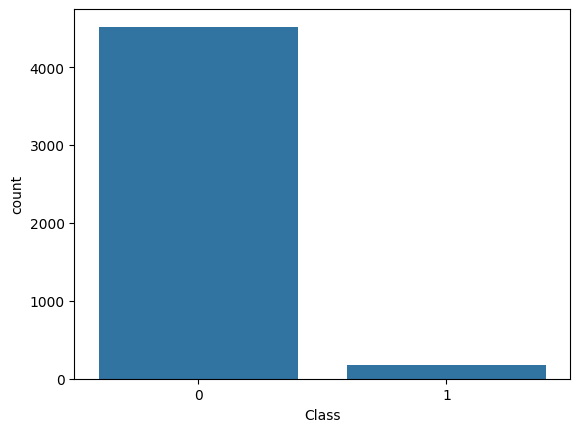

In [7]:
# create a visual plot to see the target distribution
sns.countplot(x='Class', data=data)


<Axes: xlabel='PC2', ylabel='PC5'>

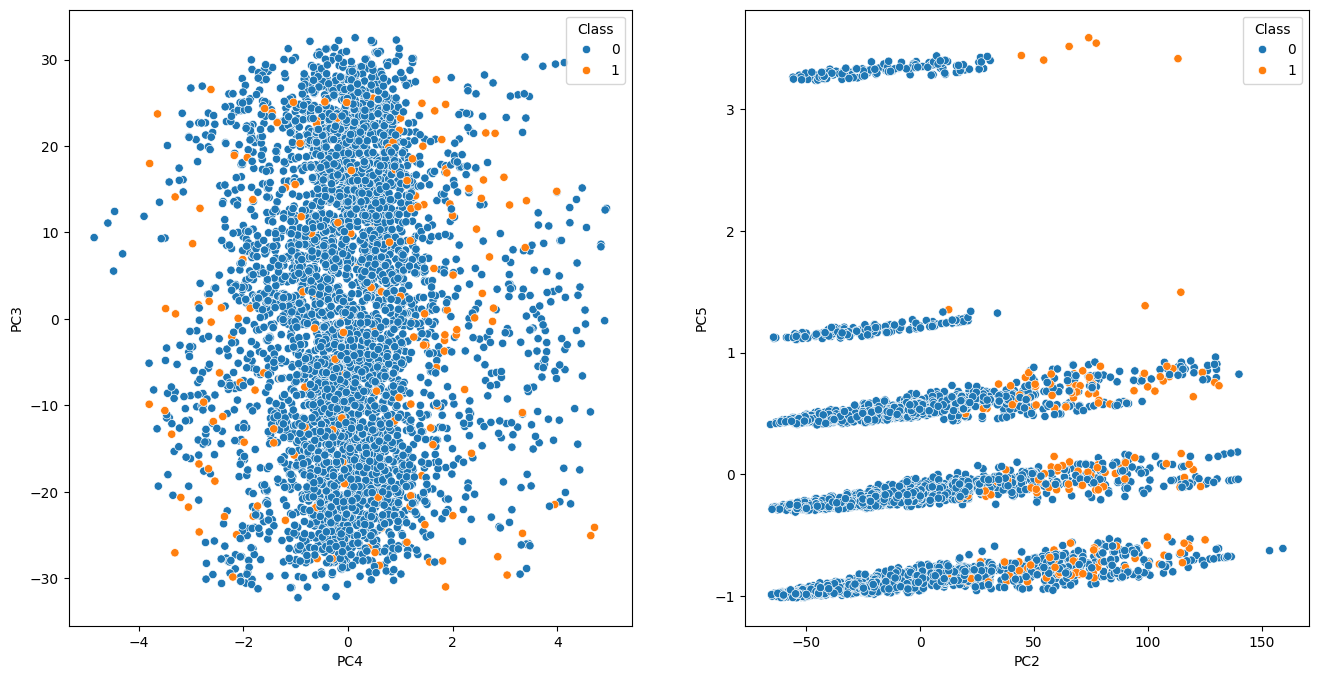

In [8]:
# create some scatterplots based on features and see if you can see some pattern in the data

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

sns.scatterplot(x='PC4', y='PC3', data=data, hue='Class', ax=ax1)
sns.scatterplot(x='PC2', y='PC5', data=data, hue='Class', ax=ax2)

<a id="4-evaluation-metric-selection"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Task 3: Evaluation Metric Selection</span>


In [9]:
# baseline accuracy of the model

round(data['Class'].value_counts(normalize=True) * 100, 2)

Class
0    96.17
1     3.83
Name: proportion, dtype: float64

For this dataset let's consider fraudulent transactions (which are denoted as 1 in the dataset) is `positive` class and the non fraudulent transactions (which are denoted as 0 in the dataset) is `negative` class.

- TP - transactions which are actually fraudulent and the model also able correctly identify them as fraudulent transactions
- FP - transactions which are actually non fraudulent transactions but the model is predicting them as fraudulent transactions
- TN - transactions which are actually non fraudulent transactions and model is also predicting them as non fraudulent transactions
- FN - transactions which are actually fraudulent but the model is predicting them as non fraudulent transactions

![alt text](images/confusion_matrix.png "confusion matrix")

Out of the misclassifications - FN (False negative) and FP (False positive) which one is costlier for this business problem?

$$recall = \frac{TP}{TP + FN}$$

$$precision = \frac{TP }{TP+ FP}$$

<a id="5-baseline-model"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Task 4: Baseline Random Forest Model</span>


In [10]:
# drop the ID variable as it is unique for all the transactions and does not have any meaningful information about the data

data = data.drop(['ID'], axis =1)

In [11]:
# extract features and target from the original dataset

features = data.drop(['Class'], axis=1)
target = data['Class']

**Beginner Note - Data Splitting:**
- `train_test_split`: We split our dataset into a 'training' set and a 'testing' set.
- The model learns patterns from the training set.
- We evaluate its real-world performance on the testing set (data it has never seen before).

In [12]:
# split the dataset into trainig and test set to train and evaluate the model respectively

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

**Beginner Note - Random Forest:**
- A Random Forest is an 'ensemble' model.
- Instead of relying on one Decision Tree, it builds many trees and has them vote on the best prediction.

In [13]:
# create a random forest model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
# predict for the test dataset

y_predict = rf.predict(X_test)

**Beginner Note - Confusion Matrix:**
- A confusion matrix visually shows how many predictions were correct vs. incorrect.
- The diagonal represents correct predictions, while off-diagonals show where the model got 'confused'.

<Axes: >

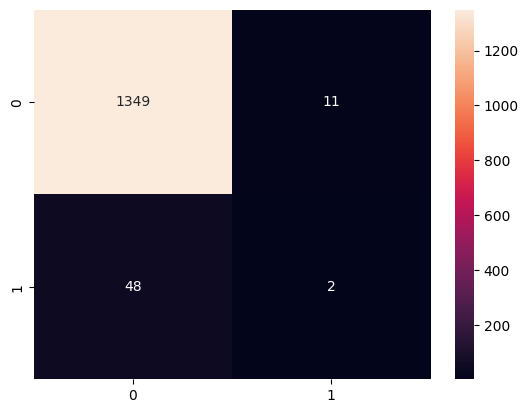

In [15]:
# plot the confusion matrix

from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_predict), annot=True, fmt='0.0f')

In [16]:
# print the classification report

from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1360
           1       0.15      0.04      0.06        50

    accuracy                           0.96      1410
   macro avg       0.56      0.52      0.52      1410
weighted avg       0.94      0.96      0.95      1410



<a id="6-resampling-techniques"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Task 5: Resampling Techniques for Imbalanced Data</span>


The imbalanced datasets are generally biased towards the majority class of the target variable. In this case the majority class is non fraudulent transactions and the minority class is fraudulent transactions. Hence if we don't balance these two classes the machine learning algorithms will be biased towards the majority class. Therefore it becomes important to balance the classes present in target variables. There are two ways in which we can balance these two categories - 

- **Undersampling**: In undersampling we randomly select as many observations of majority class as we have for minority class to make both of these classes balanced
- **Oversampling**: In oversampling, we create multiple copies of minority class to have same number of observations as we have for majority class. Here also we can oversampling in two ways - 
    - **Minotiy Oversampling**: here we create duplicates of same data from minority class
    - **SMOTE (Synthetic Minority Oversampling Technique)**: here we create observations for the minority class, based on those that already exist. It randomly picks a point from the minority class and computes the k-nearest neighbors for this point. The synthetic points are added between the chosen point and its neighbors.

![alt text](images/resampling.png "data resampling")

<a id="61-smote"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Synthetic Minority Oversampling Technique (SMOTE)</span>


![alt text](images/smote.png "SMOTE")

**Beginner Note - Imbalanced Data:**
- Our dataset has many more examples of one class than the other (imbalanced).
- **SMOTE** creates synthetic (fake but realistic) examples of the minority class so the model doesn't become biased.

In [17]:
# import imblearn library and resample the original data using SMOTE technique
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)


In [18]:
# train a random forest model on SMOTE data

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_smote, y_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

<Axes: >

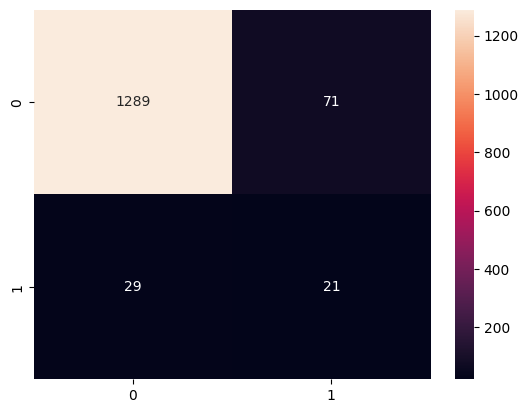

In [19]:
# predict the classes on test data using model built on SMOTE data and plot the confusion matrix

y_predict_smote = rf_smote.predict(X_test)
sns.heatmap(confusion_matrix(y_test, y_predict_smote), annot=True, fmt='0.0f')

In [20]:
# print the classification report
print(classification_report(y_test, y_predict_smote))


              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1360
           1       0.23      0.42      0.30        50

    accuracy                           0.93      1410
   macro avg       0.60      0.68      0.63      1410
weighted avg       0.95      0.93      0.94      1410



<a id="7-computing-roc-auc-curve"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Task 6: Computing ROC-AUC Curve</span>


By defualt, every machine learning algorithm uses a probability threshold of 0.5 to classify between positive and negative classes. If we can tune this probability threshold to some other values which increases the true positive rate then we will be able to increase the recall for fraudulent transactions.

To do that we need to compute the AUC score. The AUC score signifies that the probability value of a random observation from the positive class (i.e. fraudulent transactions) is larger than the probability value of another random observation from the negative class (i.e. non fraudulent transactions). AUC value of 1 means all the predicted positive (fraudulent) transactions have higher probabilites of being fraudulent than the non fraudulent transactions, which is an ideal case. 

In [ ]:
# let's compute the AUC curve for the model we developed on SMOTE data
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(10, 6))
ax = plt.gca()
RocCurveDisplay.from_estimator(rf_smote, X_test, y_test, ax=ax, curve_kwargs={'color': 'blue'})
plt.title('ROC Curve')
plt.show()


In [ ]:
# let's use another probability threshold so that we can get to the elbow position in the above curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, rf_smote.predict_proba(X_test)[:, 1])
idx = (abs(thresholds - 0.06)).argmin()

plt.figure(figsize=(10, 6))
ax = plt.gca()
RocCurveDisplay.from_estimator(rf_smote, X_test, y_test, ax=ax, curve_kwargs={'color': 'blue'})
ax.plot(fpr[idx], tpr[idx], marker='o', markersize=10, color='red', label='Threshold = 0.06')
plt.title('ROC Curve with Adjusted Threshold')
plt.legend()
plt.show()


<a id="8-adjusting-probability-threshold"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">8. Task 7: Adjusting Probability Threshold</span>


In [23]:
# compute the probabilites of test observations using rf_smote model

y_pred_prob = rf_smote.predict_proba(X_test)[:, 1]

In [24]:
# compare these probabilities against the probability threshold of 6% rather than the default threshold of 50%

y_pred_labels =(y_pred_prob >= 0.06)

**Beginner Note - Confusion Matrix:**
- A confusion matrix visually shows how many predictions were correct vs. incorrect.
- The diagonal represents correct predictions, while off-diagonals show where the model got 'confused'.

<Axes: >

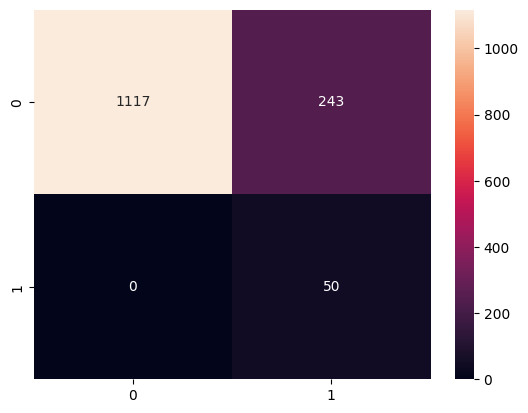

In [25]:
# plot the confusion matrix

sns.heatmap(confusion_matrix(y_test, y_pred_labels), annot=True, fmt='0.0f')

In [26]:
# print the classification report
print(classification_report(y_test, y_pred_labels))



              precision    recall  f1-score   support

           0       1.00      0.82      0.90      1360
           1       0.17      1.00      0.29        50

    accuracy                           0.83      1410
   macro avg       0.59      0.91      0.60      1410
weighted avg       0.97      0.83      0.88      1410

